In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)  #always generates same random numbers
x = np.linspace(0, 10, 50)          #50 equal nums between 0 nd 10, x is a numpy array
noise = np.random.normal(0, 1, 50)  #normally distributed random nums with mean 0 and sd of 1
y = 3 * x + 5 + noise #noise added so that values dont just end up on one line


In [25]:
def model(x,w,b):
    return w*x+b

In [ ]:
def cost_func(x,y,w,b):
    m=len(x) #number of data points
    predicted_val=model(x,w,b)
    cost=np.sum((predicted_val-y)**2)/(2*m)
    return cost


In [ ]:
def compute_gradient(x, y, w, b):
    m = len(x)
    predicted_val = model(x, w, b)
    dw = np.sum((predicted_val - y) * x) / m #d/dw
    db = np.sum(predicted_val - y) / m
    return dw, db

In [ ]:
def gradient_descent(x,y,w,b,learning_rate,max_iterations):
    tolerance=0.001 #anything around this is basically 0 the change wont matter
    cost_history = [] #tracking how well regression learns and how well error in values drops
    for i in range(max_iterations):
        dw, db = compute_gradient(x, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        cost = cost_func(x, y, w, b)
        cost_history.append(cost)
        if abs(dw) < tolerance and abs(db) < tolerance:
            break
    return w,b,cost_history

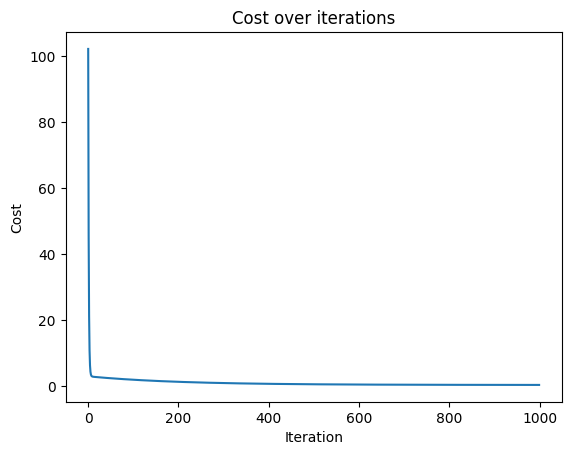

In [29]:
w_final, b_final, costs = gradient_descent(x, y, w=0, b=0, learning_rate=0.01, max_iterations=1000)
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost over iterations")
plt.show()

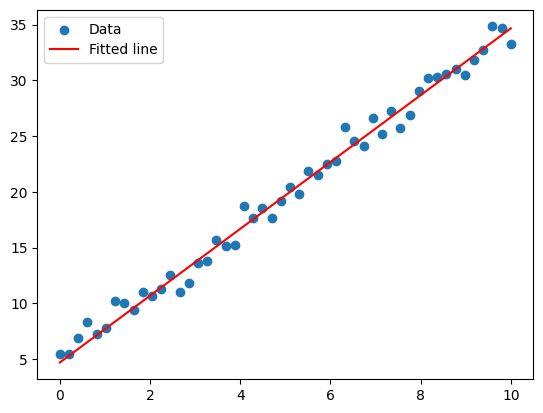

In [30]:
plt.scatter(x, y, label="Data")
plt.plot(x, model(x, w_final, b_final), color='red', label="Fitted line")
plt.legend()
plt.show()